In [ ]:
#####################################################
# Imports and Files IO
#####################################################

import pandas as pd
import os
import numpy as np 
import glob
from MDToolkit.math.smoothing import lowess 
from MDToolkit.math.differentiate import forward_finite_difference

frequency = 50 # MHz

files_dir = f"/media/jrjoseph/Elements/projects/fem_memristor/md_simulations/cscl_graphene_{frequency}MHz_ls6/"
ensembles = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

# times = ["15ns", "20ns", "25ns", "30ns", "35ns"]

# df_list = []

# for time in times:
#     file_names = [f"kcl_mos2_ensemble{ensemble}_{time}.csv" for ensemble in ensembles]

#     dfs = [pd.read_csv(os.path.join(files_dir, file_name)) for file_name in file_names]

#     df = pd.concat(dfs).groupby(level=0).mean()

#     df_list.append(df)

# print(df_list[-1])

# Multiple CSV Files

csv_files = glob.glob(f"{files_dir}/*.csv")
df_list = [pd.read_csv(file) for file in csv_files]

df = pd.concat(df_list)
df = df.groupby(df.index).mean()

In [99]:
# Manually Defined Electric Field
V_max = 1.2 # V/nm
period = 1 / (frequency * 10**6)
dt = 1 * 10 **-15 # 1 fs
V = V_max * np.sin(2*np.pi*df["timesteps"] * dt / period)

In [100]:
#####################################################
# Plotting Functions
#####################################################
import matplotlib.pyplot as plt

def plot_IV_curve(V, I, xlabel = "Applied Electric Field (V/Å)", ylabel = "Ionic Current (arb. units)", ax = None):
    plt.plot(
        V,
        I,
        linewidth=1.5,
        label="Ionic current"
    )

    # Zero reference lines
    plt.axhline(
        0,
        color="black",
        linewidth=0.8,
        linestyle="--"
    )

    plt.axvline(
        0,
        color="black",
        linewidth=0.8,
        linestyle="--"
    )

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    plt.legend(frameon=False)

    plt.tight_layout()
    plt.show()

def plot_multiple_IV_curves(Vs, Is, xlabel = "Applied Electric Field (V/Å)", ylabel = "Ionic Current (nA)", legends: list = None):
    for i in range(len(Vs)):
        if legends is None:
            label = str(i+1)
        else:
            label = legends[i]
        plt.plot(Vs[i], Is[i], linewidth = 1.5, label=label)

    # Zero reference lines
    plt.axhline(
        0,
        color="black",
        linewidth=0.8,
        linestyle="--"
    )

    plt.axvline(
        0,
        color="black",
        linewidth=0.8,
        linestyle="--"
    )

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    plt.legend(frameon=False)

    plt.tight_layout()
    plt.show()


def plot_charge_translocations(t, translocations, xlabel = "Time (fs)", ylabel = "Charge Translocations (#)", ax = None):
    plt.scatter(t, translocations)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    plt.show()

def plot_charge_translocation_wfit(t, translocations, fit_translocations, xlabel = "Time (fs)", ylabel = "Charge Translocations (#)", ax = None, plot_raw_every_n = 100):
    plt.scatter(t[::plot_raw_every_n], translocations[::plot_raw_every_n], label = "raw", color = "red")
    plt.plot(t, fit_translocations, label = "fitted")
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)

    plt.legend()

    plt.show()

def plot_ion_translocations(translocations_df_list: list[pd.DataFrame], xlabel = "Time (fs)", ylabel = "Ion Translocations (#)", cmap = "tab10", ax = None):
    cmap = plt.colormaps[cmap]

    colors = cmap(np.linspace(0, 1, len(translocations_df_list)))

    for j in range(len(translocations_df_list)):
        symbs = ["s", "*"]
        plotting_columns = translocations_df_list[j].columns[-2:]
        master_label = "".join([col.split("_")[-1] for col in plotting_columns])
        for i in range(len(plotting_columns)):
            running_sum = np.cumsum(translocations_df_list[j][plotting_columns[i]])
            plt.plot(translocations_df_list[j].iloc[:, 0], running_sum, label = f'{plotting_columns[i].split("_")[-1]}-{master_label}', marker = symbs[i], markevery=500, color = colors[j])

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

    plt.show()


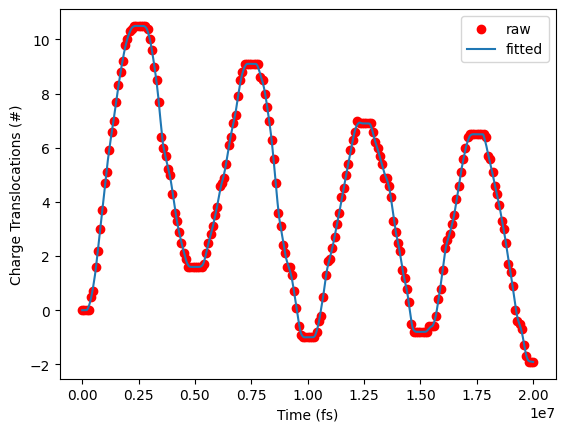

In [ ]:
x, y = lowess(df["timesteps"], df["cumulative_charge_translocation"], window=1500)

dydx = forward_finite_difference(np.array(x), np.array(y))

plot_charge_translocation_wfit(df["timesteps"], df["cumulative_charge_translocation"], y)

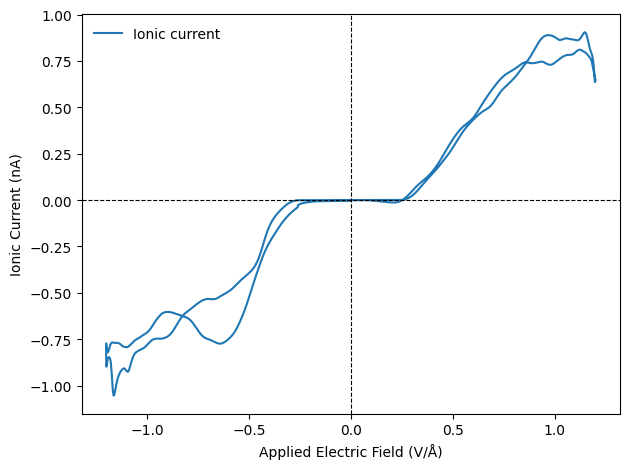

In [102]:
import scipy.constants as scc

Ts = np.array(df["timesteps"])

Ts = Ts[:-1]
dydx = np.array(dydx[:-1])
V = np.array(V[:-1])

period_indices = (Ts // (period / dt)).astype(int)
n_periods = np.max(period_indices) + 1

Ts = [Ts[period_indices == i] for i in range(n_periods)]

Is = [dydx[period_indices == i] for i in range(n_periods)]
Vs = [V[period_indices == i] for i in range(n_periods)]

I = np.mean(np.stack(Is), axis=0)
V = np.mean(np.stack(Vs), axis=0)

plot_IV_curve(V, I * scc.e * 10**15 * 10**9, ylabel="Ionic Current (nA)")